# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, score, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 67
Columns: ['commit', 'score', 'action_ce', 'latency_ms', 'memory_gb', 'status', 'description']


,commit,score,action_ce,latency_ms,memory_gb,status,description
0,6a86a5a,-2.757567,1.896510,344.4,1.3,KEEP,baseline SmolVLM2-500M frozen backbone
1,7649eb9,-2.731882,1.894990,334.8,1.0,KEEP,layer skip 16/32 LM layers
2,ce47a94,-3.430920,1.816429,645.8,0.9,DISCARD,layer skip 4/32 + batch 8 (latency regression)
3,c09689f,-4.374720,3.452643,368.8,1.0,DISCARD,feature caching (overfit on 1296 cached windows)
4,d415b09,-2.804490,1.953368,340.5,0.7,DISCARD,"SmolVLM2-256M (worse features, same speed)"
5,f9b154e,-2.851289,1.941116,364.1,1.0,DISCARD,workers=4 + LR 2e-4 (workers add overhead)
6,e4ad46a,-1.502109,1.432463,27.9,1.0,KEEP,"bypass HF processor (GPU resize+normalize, cac..."
7,d39587e,-1.626505,1.552987,29.4,1.1,DISCARD,depth 6 (fewer steps outweighs capacity)
8,07be5f0,-1.717797,1.615032,41.1,1.3,DISCARD,"full 32 layers (too slow, worse features not w..."
9,4338ca5,0.000000,0.000000,0.0,0.0,CRASH,native 256x256 (CUDA assert in inputs_merger)


In [38]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    47
KEEP       18
CRASH       2

Keep rate: 18/65 = 27.7%


In [39]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["score"]
    desc = row["description"]
    print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (18 total):

  #  0  bpb=-2.757567  mem=1.3GB  baseline SmolVLM2-500M frozen backbone
  #  1  bpb=-2.731882  mem=1.0GB  layer skip 16/32 LM layers
  #  6  bpb=-1.502109  mem=1.0GB  bypass HF processor (GPU resize+normalize, cached tokenization)
  # 15  bpb=-1.494067  mem=0.9GB  LoRA r16 on 8 LM layers (matches 16-layer frozen, better latency)
  # 22  bpb=-1.484302  mem=0.9GB  label smoothing 0.1 (minor regularization benefit)
  # 26  bpb=-1.398934  mem=0.9GB  past_action_chunk 4 (big win: shorter seq, less noise from old actions)
  # 27  bpb=-1.382741  mem=0.9GB  past_action_chunk 2 (continuing improvement)
  # 29  bpb=-1.380687  mem=0.9GB  past_action_chunk 1 (shortest with temporal info)
  # 30  bpb=-1.358606  mem=0.9GB  LR 1.5e-4 (better with shorter sequence)
  # 35  bpb=-1.355019  mem=0.9GB  weight decay 0.005 (marginal improvement)
  # 39  bpb=-1.333477  mem=0.8GB  8 frozen no LoRA (more steps > LoRA adaptation!)
  # 43  bpb=-1.294475  mem=0.9GB  DEVICE_BATCH 8 (

## Score Over Time

Track how the best kept score evolves as experiments progress. The running maximum shows the "frontier" -- the best result achieved so far when higher scores are better.

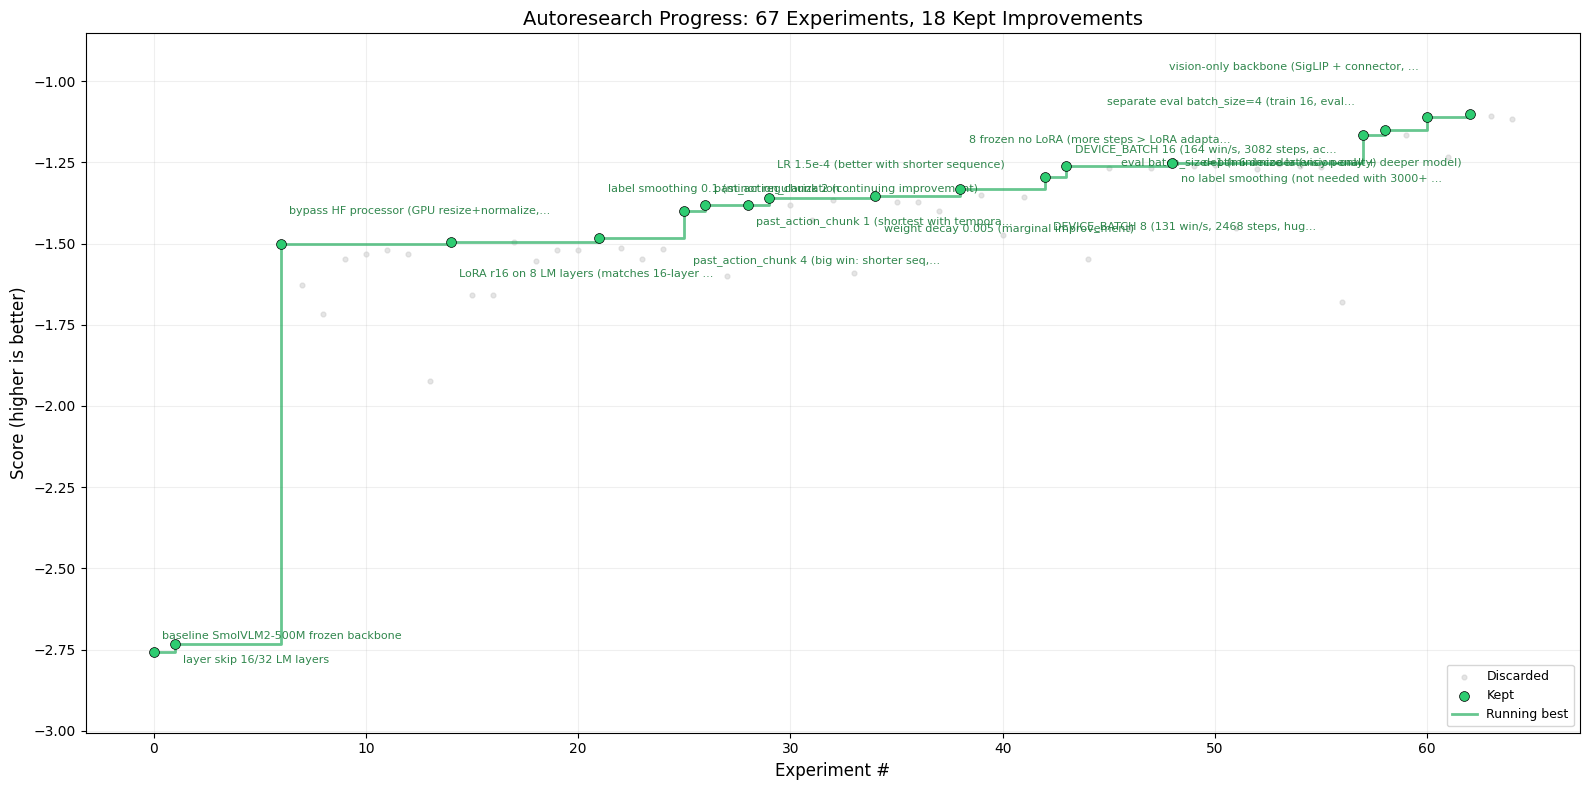

Saved to progress.png


In [40]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_score = valid.loc[0, "score"]

# Only plot points at or above baseline (the interesting region)
above = valid[valid["score"] >= baseline_score - 0.0005]

# Plot discarded as faint background dots
disc = above[above["status"] == "DISCARD"]
ax.scatter(disc.index, disc["score"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = above[above["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["score"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running maximum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_score = valid.loc[kept_mask, "score"]
running_max = kept_score.cummax()
ax.step(kept_idx, running_max, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Alternate labels above and below points to reduce collisions
label_offsets = [(6, 8), (6, -8), (6, 20), (6, -20), (6, 32), (6, -32)]
for label_i, (idx, score) in enumerate(zip(kept_idx, kept_score)):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    xoff, yoff = label_offsets[label_i % len(label_offsets)]
    if idx >= kept_idx.max() - 6:
        xoff = -6

    ha = "left" if xoff > 0 else "right"
    va = "bottom" if yoff > 0 else "top"

    ax.annotate(desc, (idx, score),
                textcoords="offset points",
                xytext=(xoff, yoff), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                ha=ha, va=va)

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Score (higher is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below baseline to just above best
best = kept_score.max()
margin = (best - baseline_score) * 0.15
ax.set_ylim(baseline_score - margin, best + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [41]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["score"]
best_bpb = kept["score"].min()
best_row = kept.loc[kept["score"].idxmin()]

print(f"Baseline score:  {baseline_bpb:.6f}")
print(f"Best score:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['score']:.6f}  {desc}")

Baseline score:  -2.757567
Best score:      -2.757567
Total improvement: 0.000000 (-0.00%)
Best experiment:   baseline SmolVLM2-500M frozen backbone

Cumulative effort per improvement:
  Experiment #  0: bpb=-2.757567  baseline SmolVLM2-500M frozen backbone
  Experiment #  1: bpb=-2.731882  layer skip 16/32 LM layers
  Experiment #  6: bpb=-1.502109  bypass HF processor (GPU resize+normalize, cached tokenization)
  Experiment # 15: bpb=-1.494067  LoRA r16 on 8 LM layers (matches 16-layer frozen, better latency)
  Experiment # 22: bpb=-1.484302  label smoothing 0.1 (minor regularization benefit)
  Experiment # 26: bpb=-1.398934  past_action_chunk 4 (big win: shorter seq, less noise from old actions)
  Experiment # 27: bpb=-1.382741  past_action_chunk 2 (continuing improvement)
  Experiment # 29: bpb=-1.380687  past_action_chunk 1 (shortest with temporal info)
  Experiment # 30: bpb=-1.358606  LR 1.5e-4 (better with shorter sequence)
  Experiment # 35: bpb=-1.355019  weight decay 0.005 (

## Top Hits (Kept Experiments by Improvement)

In [42]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["score"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["score"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['score']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  -0.002054  -1.380687  past_action_chunk 1 (shortest with temporal info)
   2  -0.003587  -1.355019  weight decay 0.005 (marginal improvement)
   3  -0.007218  -1.253015  no label smoothing (not needed with 3000+ steps)
   4  -0.007925  -1.101290  depth 6 decoder (vision-only + deeper model)
   5  -0.008042  -1.494067  LoRA r16 on 8 LM layers (matches 16-layer frozen, better latency)
   6  -0.009765  -1.484302  label smoothing 0.1 (minor regularization benefit)
   7  -0.015885  -1.149304  eval batch_size=1 (minimize latency penalty)
   8  -0.016193  -1.382741  past_action_chunk 2 (continuing improvement)
   9  -0.021542  -1.333477  8 frozen no LoRA (more steps > LoRA adaptation!)
  10  -0.022081  -1.358606  LR 1.5e-4 (better with shorter sequence)
  11  -0.025685  -2.731882  layer skip 16/32 LM layers
  12  -0.034242  -1.260233  DEVICE_BATCH 16 (164 win/s, 3082 